In [1]:
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "Data"

print(f"Using device: {device}")
print(f"Dataset folder exists: {DATA_DIR.exists()}")

Using device: cpu
Dataset folder exists: True


In [3]:
scan_records = []

for class_name, label in [("Hemorrhagic", 1), ("NORMAL", 0)]:
    class_dir = DATA_DIR / class_name

    for folder in class_dir.rglob("*"):
        if folder.is_dir() and any(folder.glob("*.jpg")):
            scan_records.append(
                {
                    "scan_id": str(folder.relative_to(DATA_DIR)),
                    "class_name": class_name,
                    "label": label,
                    "slice_count": len(list(folder.glob("*.jpg"))),
                }
            )

scans_df = pd.DataFrame(scan_records)

print(f"Total scans found: {len(scans_df)}")
scans_df["class_name"].value_counts()

Total scans found: 45


class_name
NORMAL         27
Hemorrhagic    18
Name: count, dtype: int64

In [4]:
excluded_scan_id = r"NORMAL\N27[N27]"

scans_df_clean = (
    scans_df[scans_df["scan_id"] != excluded_scan_id]
    .copy()
    .reset_index(drop=True)
)

print(f"Scans used for CNN–LSTM: {len(scans_df_clean)}")
scans_df_clean["class_name"].value_counts()

Scans used for CNN–LSTM: 44


class_name
NORMAL         26
Hemorrhagic    18
Name: count, dtype: int64

In [5]:
train_val_scans, test_scans = train_test_split(
    scans_df_clean,
    test_size=0.20,
    stratify=scans_df_clean["label"],
    random_state=SEED,
)

train_scans, val_scans = train_test_split(
    train_val_scans,
    test_size=0.1875,
    stratify=train_val_scans["label"],
    random_state=SEED,
)

In [6]:
def get_ordered_slice_paths(scan_id):
    scan_folder = DATA_DIR / scan_id

    slice_paths = list(scan_folder.glob("*.jpg"))

    return sorted(
        slice_paths,
        key=lambda path: int(re.findall(r"\d+", path.stem)[-1]),
    )

In [7]:
from torchvision import models
from torchvision.models import ResNet18_Weights

RESNET_WEIGHTS = ResNet18_Weights.DEFAULT

# RGB + ImageNet normalization required by pretrained ResNet-18
sequence_transform = RESNET_WEIGHTS.transforms()

SEQUENCE_LENGTH = 16

In [8]:
def select_evenly_spaced_slices(slice_paths, sequence_length):
    indices = np.linspace(
        0,
        len(slice_paths) - 1,
        num=sequence_length,
        dtype=int,
    )
    return [slice_paths[index] for index in indices]


class ResNetSequenceDataset(Dataset):
    def __init__(self, scans_df, transform, sequence_length):
        self.scans_df = scans_df.reset_index(drop=True)
        self.transform = transform
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.scans_df)

    def __getitem__(self, index):
        scan = self.scans_df.iloc[index]

        ordered_paths = get_ordered_slice_paths(scan["scan_id"])
        selected_paths = select_evenly_spaced_slices(
            ordered_paths,
            self.sequence_length,
        )

        slices = []
        for path in selected_paths:
            image = Image.open(path).convert("RGB")
            slices.append(self.transform(image))

        sequence = torch.stack(slices)  # [16, 3, 224, 224]
        label = torch.tensor(scan["label"], dtype=torch.long)

        return sequence, label

In [9]:
BATCH_SIZE = 2

train_dataset = ResNetSequenceDataset(
    train_scans,
    transform=sequence_transform,
    sequence_length=SEQUENCE_LENGTH,
)

val_dataset = ResNetSequenceDataset(
    val_scans,
    transform=sequence_transform,
    sequence_length=SEQUENCE_LENGTH,
)

test_dataset = ResNetSequenceDataset(
    test_scans,
    transform=sequence_transform,
    sequence_length=SEQUENCE_LENGTH,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train scans: {len(train_dataset)}")
print(f"Validation scans: {len(val_dataset)}")
print(f"Test scans: {len(test_dataset)}")

Train scans: 28
Validation scans: 7
Test scans: 9


In [10]:
sequences, labels = next(iter(train_loader))

print("Sequence batch shape:", sequences.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels.tolist())
print("Pixel range:", sequences.min().item(), "to", sequences.max().item())

Sequence batch shape: torch.Size([2, 16, 3, 224, 224])
Label batch shape: torch.Size([2])
Labels: [0, 0]
Pixel range: -2.1179039478302 to 2.640000104904175


In [11]:
class ResNetBiLSTM(nn.Module):
    def __init__(self, hidden_size=128, num_classes=2):
        super().__init__()

        resnet = models.resnet18(weights=RESNET_WEIGHTS)

        # Keep every ResNet layer except its final classifier.
        self.feature_extractor = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        # Phase 1: keep pretrained image features fixed.
        for parameter in self.feature_extractor.parameters():
            parameter.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(hidden_size * 2, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)

        # Keep frozen ResNet BatchNorm statistics unchanged.
        self.feature_extractor.eval()
        return self

    def forward(self, x):
        # Input: [batch, slices, 3, 224, 224]
        batch_size, sequence_length, channels, height, width = x.shape

        x = x.view(batch_size * sequence_length, channels, height, width)

        # ResNet extracts a 512-number feature vector for every slice.
        with torch.no_grad():
            features = self.feature_extractor(x).flatten(1)

        features = features.view(batch_size, sequence_length, -1)

        _, (hidden, _) = self.lstm(features)

        # Combine final forward and backward LSTM information.
        scan_features = torch.cat((hidden[-2], hidden[-1]), dim=1)

        return self.classifier(scan_features)

In [12]:
model = ResNetBiLSTM().to(device)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

model.eval()

with torch.no_grad():
    sample_logits = model(sequences.to(device))

print("Input shape:", sequences.shape)
print("Output logits shape:", sample_logits.shape)
print("Sample logits:", sample_logits.cpu())

Total parameters: 11,834,434
Trainable parameters: 657,922
Input shape: torch.Size([2, 16, 3, 224, 224])
Output logits shape: torch.Size([2, 2])
Sample logits: tensor([[-0.0391, -0.3100],
        [-0.1014, -0.1829]])


In [13]:
class_counts = train_scans["label"].value_counts().sort_index()

class_weights = torch.tensor(
    len(train_scans) / (2 * class_counts.values),
    dtype=torch.float32,
).to(device)

print("Training scans per class:")
print(class_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=5e-4,
    weight_decay=1e-4,
)

Training scans per class:
label
0    17
1    11
Name: count, dtype: int64
Class weights: tensor([0.8235, 1.2727])


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_scans = 0

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        predictions = logits.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_scans += labels.size(0)

    average_loss = total_loss / total_scans
    accuracy = correct_predictions / total_scans

    return average_loss, accuracy

In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_scans = 0

    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            logits = model(sequences)
            loss = criterion(logits, labels)

            probabilities = torch.softmax(logits, dim=1)[:, 1]
            predictions = logits.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (predictions == labels).sum().item()
            total_scans += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    average_loss = total_loss / total_scans
    accuracy = correct_predictions / total_scans
    auc = roc_auc_score(all_labels, all_probabilities)

    return average_loss, accuracy, auc, all_labels, all_probabilities

In [16]:
MAX_EPOCHS = 15
PATIENCE = 5

MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

checkpoint_path = MODELS_DIR / "resnet18_bilstm_best.pt"

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_auc": [],
}

best_val_auc = float("-inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_accuracy, val_auc, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_auc"].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_epoch": best_epoch,
                "best_val_auc": best_val_auc,
                "sequence_length": SEQUENCE_LENGTH,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest validation AUC: {best_val_auc:.4f} (Epoch {best_epoch})")
print(f"Saved best model to: {checkpoint_path}")

Epoch 01/15 | Train loss: 0.9815 | Train acc: 0.6071 | Val loss: 0.7268 | Val acc: 0.5714 | Val AUC: 0.4167
Epoch 02/15 | Train loss: 0.7255 | Train acc: 0.5000 | Val loss: 0.7106 | Val acc: 0.5714 | Val AUC: 0.5000
Epoch 03/15 | Train loss: 0.6393 | Train acc: 0.6429 | Val loss: 0.7370 | Val acc: 0.5714 | Val AUC: 0.5833
Epoch 04/15 | Train loss: 0.5595 | Train acc: 0.8214 | Val loss: 0.7275 | Val acc: 0.5714 | Val AUC: 0.6667
Epoch 05/15 | Train loss: 0.5039 | Train acc: 0.8214 | Val loss: 0.7073 | Val acc: 0.5714 | Val AUC: 0.7500
Epoch 06/15 | Train loss: 0.4955 | Train acc: 0.7500 | Val loss: 0.7702 | Val acc: 0.5714 | Val AUC: 0.8333
Epoch 07/15 | Train loss: 0.3976 | Train acc: 0.8929 | Val loss: 0.6600 | Val acc: 0.5714 | Val AUC: 0.9167
Epoch 08/15 | Train loss: 0.3531 | Train acc: 0.9286 | Val loss: 0.6524 | Val acc: 0.5714 | Val AUC: 0.9167
Epoch 09/15 | Train loss: 0.3094 | Train acc: 0.9286 | Val loss: 0.6774 | Val acc: 0.5714 | Val AUC: 0.9167
Epoch 10/15 | Train loss: 0.

In [17]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(checkpoint["model_state_dict"])

val_loss, val_accuracy, val_auc, val_labels, val_probabilities = evaluate(
    model,
    val_loader,
    criterion,
    device,
)

validation_results = val_scans[
    ["scan_id", "class_name"]
].reset_index(drop=True).copy()

validation_results["hemorrhage_probability"] = val_probabilities
validation_results["prediction_at_0_5"] = np.where(
    validation_results["hemorrhage_probability"] >= 0.5,
    "Hemorrhagic",
    "NORMAL",
)

print(f"Best checkpoint epoch: {checkpoint['best_epoch']}")
print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation accuracy at 0.5: {val_accuracy:.4f}")

validation_results.sort_values(
    "hemorrhage_probability"
).reset_index(drop=True)

Best checkpoint epoch: 11
Validation AUC: 1.0000
Validation accuracy at 0.5: 0.5714


,scan_id,class_name,hemorrhage_probability,prediction_at_0_5
0,NORMAL\N11[N11],NORMAL,0.076818,NORMAL
1,NORMAL\N9[N9],NORMAL,0.084932,NORMAL
2,NORMAL\N6[N6],NORMAL,0.100069,NORMAL
3,NORMAL\N5[N5],NORMAL,0.121774,NORMAL
4,Hemorrhagic\KANAMA\7[7],Hemorrhagic,0.133373,NORMAL
5,Hemorrhagic\KANAMA\5[5],Hemorrhagic,0.191809,NORMAL
6,Hemorrhagic\KANAMA\8[8],Hemorrhagic,0.231678,NORMAL


In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    val_labels,
    val_probabilities,
)

youden_j = tpr - fpr
best_threshold_index = np.argmax(youden_j)

decision_threshold = thresholds[best_threshold_index]

print(f"Chosen validation threshold: {decision_threshold:.4f}")
print(f"Validation sensitivity: {tpr[best_threshold_index]:.4f}")
print(f"Validation specificity: {1 - fpr[best_threshold_index]:.4f}")

Chosen validation threshold: 0.1334
Validation sensitivity: 1.0000
Validation specificity: 1.0000


In [19]:
test_loss, test_accuracy_at_0_5, test_auc, test_labels, test_probabilities = evaluate(
    model,
    test_loader,
    criterion,
    device,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Test accuracy at default 0.5: {test_accuracy_at_0_5:.4f}")
print(f"Validation-selected threshold: {decision_threshold:.4f}")

Test loss: 0.7442
Test ROC-AUC: 0.7000
Test accuracy at default 0.5: 0.6667
Validation-selected threshold: 0.1334


In [20]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

test_predictions = (
    np.array(test_probabilities) >= decision_threshold
).astype(int)

print(f"Accuracy: {accuracy_score(test_labels, test_predictions):.4f}")
print(
    f"Balanced accuracy: "
    f"{balanced_accuracy_score(test_labels, test_predictions):.4f}"
)
print(
    f"Precision: "
    f"{precision_score(test_labels, test_predictions, zero_division=0):.4f}"
)
print(
    f"Sensitivity / recall: "
    f"{recall_score(test_labels, test_predictions, zero_division=0):.4f}"
)
print(
    f"Specificity: "
    f"{recall_score(test_labels, test_predictions, pos_label=0, zero_division=0):.4f}"
)
print(f"F1-score: {f1_score(test_labels, test_predictions, zero_division=0):.4f}")
print(f"PR-AUC: {average_precision_score(test_labels, test_probabilities):.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(test_labels, test_predictions, labels=[0, 1]))

print("\nClassification report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["NORMAL", "Hemorrhagic"],
        zero_division=0,
    )
)

Accuracy: 0.5556
Balanced accuracy: 0.5750
Precision: 0.5000
Sensitivity / recall: 0.7500
Specificity: 0.4000
F1-score: 0.6000
PR-AUC: 0.7292

Confusion matrix:
[[2 3]
 [1 3]]

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.67      0.40      0.50         5
 Hemorrhagic       0.50      0.75      0.60         4

    accuracy                           0.56         9
   macro avg       0.58      0.57      0.55         9
weighted avg       0.59      0.56      0.54         9



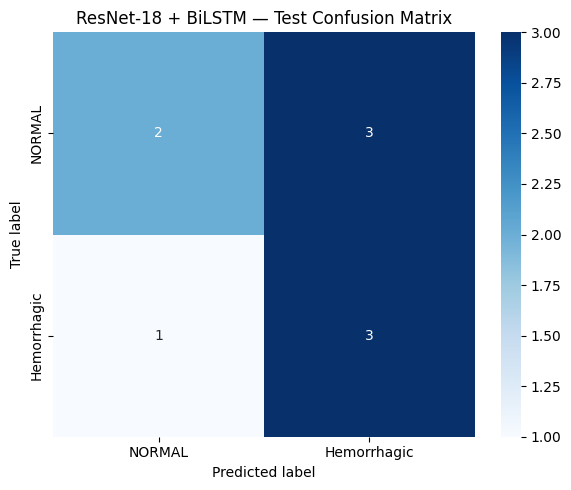

In [21]:
cm = confusion_matrix(test_labels, test_predictions, labels=[0, 1])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "Hemorrhagic"],
    yticklabels=["NORMAL", "Hemorrhagic"],
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("ResNet-18 + BiLSTM — Test Confusion Matrix")
plt.tight_layout()
plt.show()

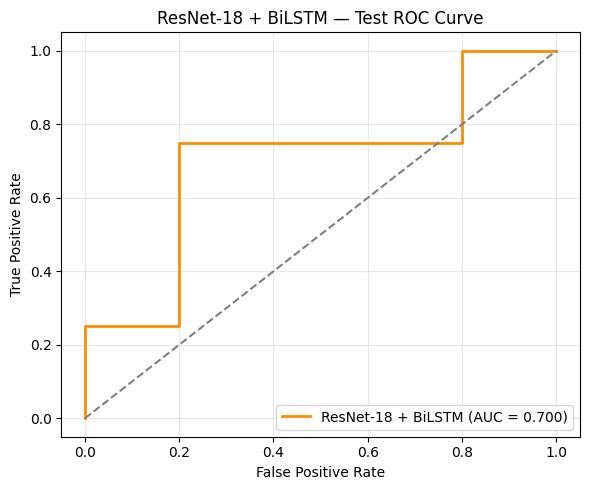

In [22]:
test_fpr, test_tpr, _ = roc_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    test_fpr,
    test_tpr,
    color="darkorange",
    linewidth=2,
    label=f"ResNet-18 + BiLSTM (AUC = {test_auc:.3f})",
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet-18 + BiLSTM — Test ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

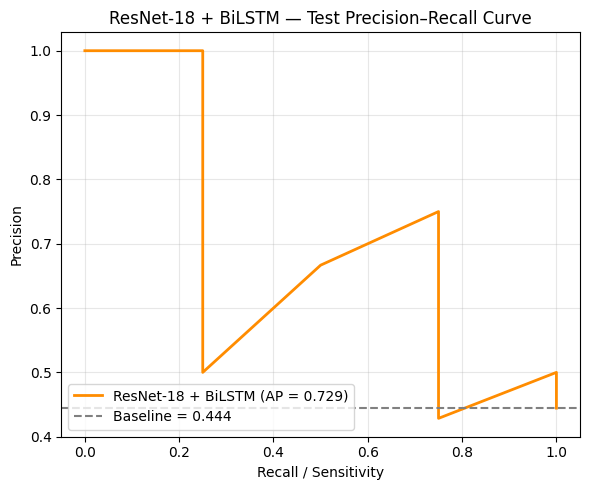

In [23]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    test_labels,
    test_probabilities,
)

baseline = np.mean(test_labels)

plt.figure(figsize=(6, 5))

plt.plot(
    recall,
    precision,
    color="darkorange",
    linewidth=2,
    label=f"ResNet-18 + BiLSTM (AP = {average_precision_score(test_labels, test_probabilities):.3f})",
)

plt.axhline(
    baseline,
    linestyle="--",
    color="gray",
    label=f"Baseline = {baseline:.3f}",
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("ResNet-18 + BiLSTM — Test Precision–Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

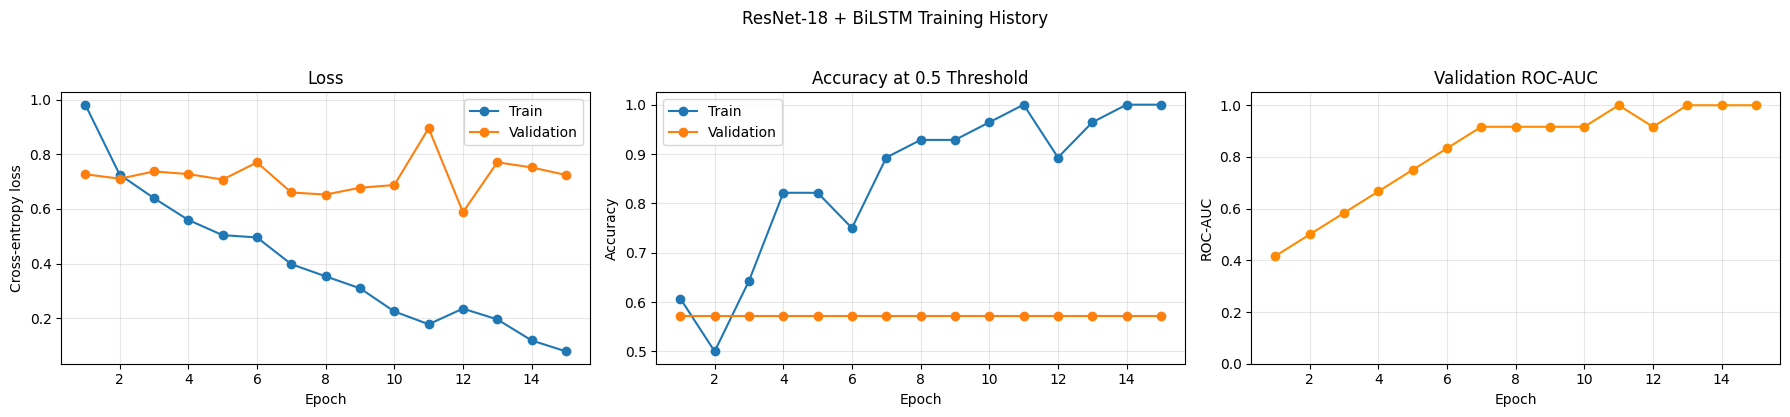

In [24]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Train")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation")
axes[1].set_title("Accuracy at 0.5 Threshold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history["val_auc"], marker="o", color="darkorange")
axes[2].set_title("Validation ROC-AUC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_ylim(0, 1.05)
axes[2].grid(alpha=0.3)

plt.suptitle("ResNet-18 + BiLSTM Training History", y=1.03)
plt.tight_layout()
plt.show()